In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
import qcodes as qc
import scienceplots

In [2]:
plt.style.use(["science", "no-latex"])

In [3]:
def autocorrelation_fit(tau, tau0, tau_a, p):
    return 1 - p * np.exp(-2 * (np.abs(tau - tau0) / tau_a))

In [4]:
def extract_fit_and_plot(filename, filename_save = "g(2)", save = False):
    RF_data = np.loadtxt(f"{filename}", skiprows=1)
    y_norm = RF_data[:,1] / np.mean(RF_data[50,1])
    x = RF_data[:,0]
    
    p0 = [-2300, 500, -1]
    popt, pcov = curve_fit(autocorrelation_fit, x, y_norm, p0)
    print(popt)
    plt.figure(figsize = (8,6))
    plt.plot(x, y_norm, ".", label = "data")
    plt.plot(x, autocorrelation_fit(x, *popt), label = "fit", color = "red")
    #plt.plot(x, autocorrelation_fit(x, *p0), label = "guess", color = "green")
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    plt.xlabel("τ [ps]", fontsize = 18)
    plt.ylabel("g²(τ)", fontsize = 18)
    #plt.legend()
    if save == True:
        plt.savefig("g2_RF.png", dpi = 300)
    plt.show()

[-2.32533700e+03  1.09976243e+03  5.25626257e-01]


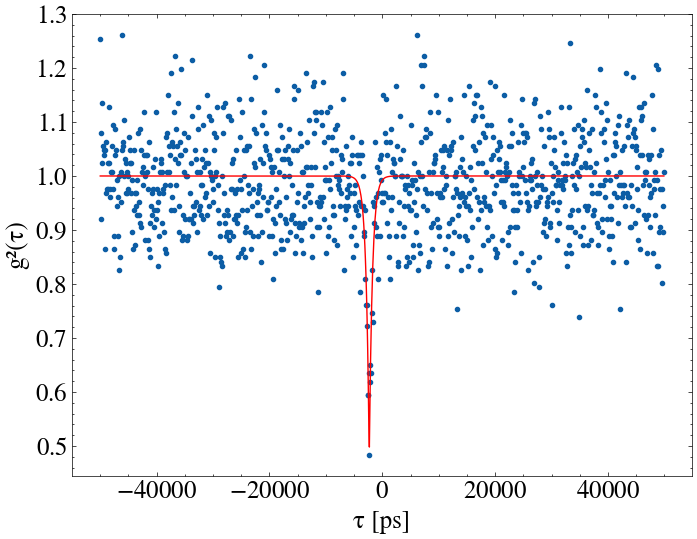

In [5]:
extract_fit_and_plot("RF_less_shit_g2.txt")

[-2.28234259e+03  1.13040956e+03  4.11949601e-01]


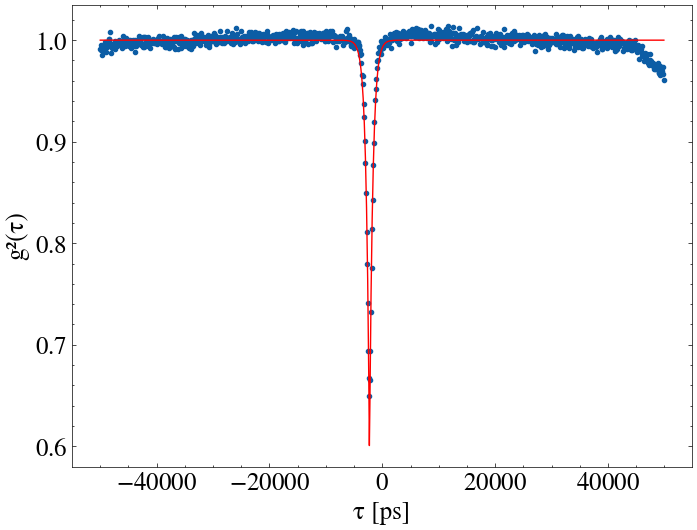

In [6]:
extract_fit_and_plot("RF_shit_g2_more_countsa.txt", save=True)

[-2.31446143e+03  9.50878414e+02  3.83519508e-01]


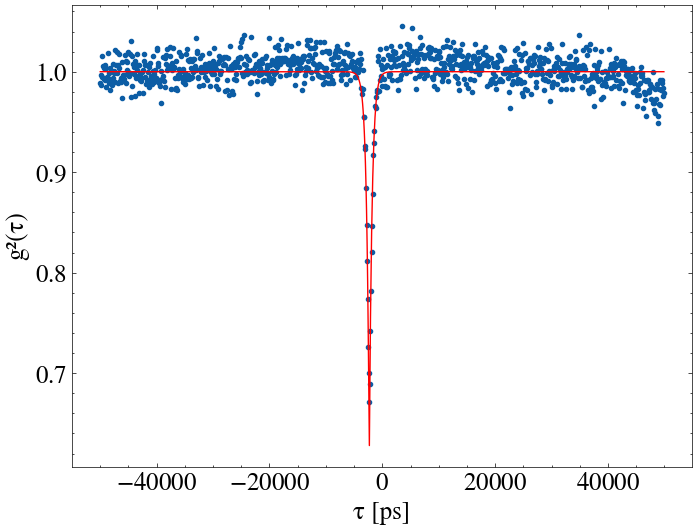

In [7]:
extract_fit_and_plot("RF_shit_g2.txt")